# YOLO Results Comparison and Performance Analysis

This notebook presents a comparative analysis of multiple YOLO models and experiments.
The evaluation focuses on key performance metrics such as mAP, precision, recall, and inference time.
The goal is to identify performance differences between model variants, training configurations, and datasets, and to provide clear, data-driven conclusions.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from supabase_auth import model
from ultralytics import YOLO

In [3]:
# First model experiment
# 200 training images (Not enough images, just for run the model and look the performance)
model_smbt_9 = YOLO('../01_notebooks/runs/detect/smbt_detection_9/weights/best.pt')

In [4]:
model_smbt_9.info()

Model summary: 129 layers, 11,137,148 parameters, 0 gradients, 28.7 GFLOPs


(129, 11137148, 0, 28.6534144)

In [5]:
smbt_detection_9 = pd.read_csv(
    '../01_notebooks/runs/detect/smbt_detection_9/results.csv'
)

In [6]:
# Training time is around 2 hours
training_time = smbt_detection_9.time.tail(1) / 60 / 60
training_time

218    2.012336
Name: time, dtype: float64

In [7]:
smbt_detection_9

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,34.2120,1.97623,4.14299,1.91285,0.62586,0.25833,0.30907,0.23568,1.50186,4.99774,1.63373,0.000313,0.000313,0.000313
1,2,69.1891,1.87755,3.04730,1.76564,0.16743,0.35000,0.19564,0.05696,1.66740,10.13790,1.81461,0.000635,0.000635,0.000635
2,3,103.5110,1.74676,2.66285,1.68759,0.17061,0.55438,0.32296,0.13066,1.63389,6.02432,1.71888,0.000955,0.000955,0.000955
3,4,137.1390,1.83223,2.65304,1.73143,0.86746,0.24979,0.32193,0.14471,1.38153,4.38784,1.80680,0.001235,0.001235,0.001235
4,5,171.6720,1.80830,2.54298,1.71234,0.23873,0.35183,0.25246,0.12168,1.50840,5.53864,1.67069,0.001230,0.001230,0.001230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,215,7157.9500,0.55114,0.48430,0.96332,0.91183,0.69645,0.73997,0.59781,1.04741,0.66720,1.28420,0.000191,0.000191,0.000191
215,216,7179.4300,0.59675,0.54776,0.98281,0.91957,0.69527,0.73969,0.59869,1.05361,0.66740,1.29546,0.000186,0.000186,0.000186
216,217,7201.2800,0.54515,0.48018,0.94776,0.91621,0.69395,0.73987,0.60683,1.00704,0.68704,1.26597,0.000181,0.000181,0.000181
217,218,7222.7400,0.52129,0.45216,0.95137,0.90751,0.69409,0.81898,0.61404,0.99924,0.69353,1.26328,0.000176,0.000176,0.000176


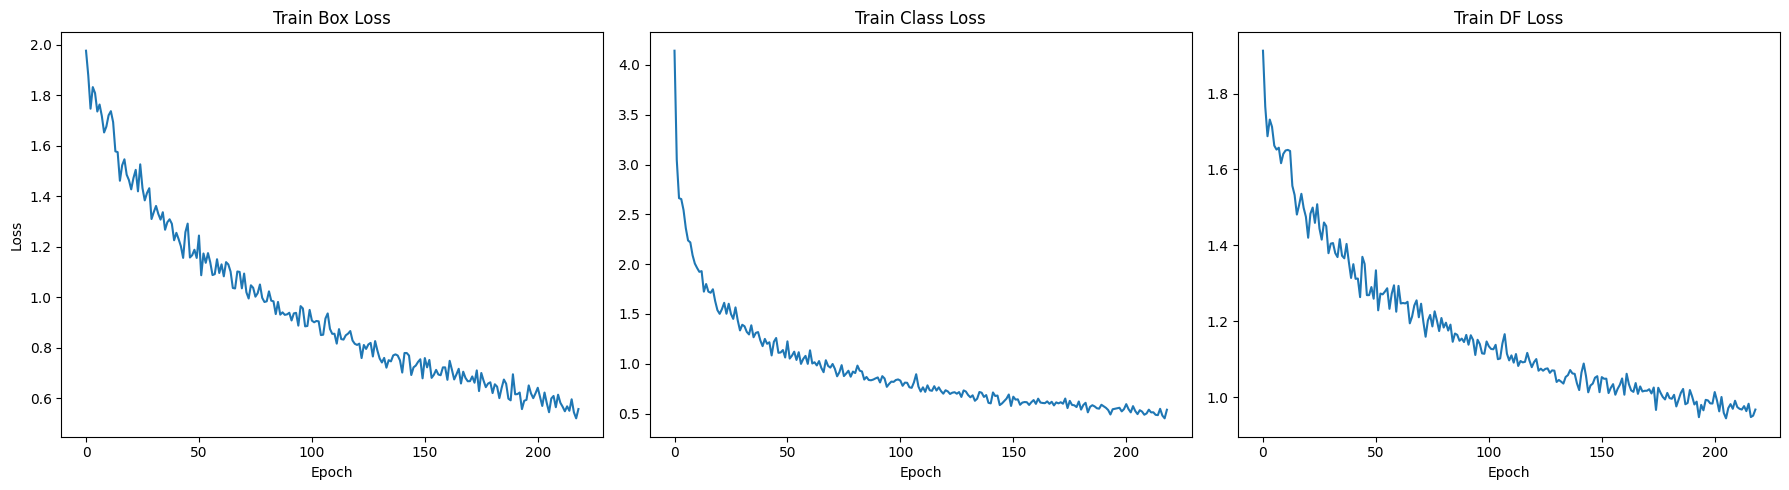

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Box loss
axes[0].plot(smbt_detection_9.index, smbt_detection_9['train/box_loss'])
axes[0].set_title('Train Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# Class loss
axes[1].plot(smbt_detection_9.index, smbt_detection_9['train/cls_loss'])
axes[1].set_title('Train Class Loss')
axes[1].set_xlabel('Epoch')

# DFL loss
axes[2].plot(smbt_detection_9.index, smbt_detection_9['train/dfl_loss'])
axes[2].set_title('Train DF Loss')
axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

In [9]:
from ultralytics.utils.loss import BboxLoss, TVPDetectLoss
import inspect

## <span style="color:#1f77b4;">I. TRAIN BOX LOSS | What happens during training in each batch</span>

During **training**, for **each image in a batch**, the following two main steps occur:

### 1. Prediction
The model processes the input image and **predicts**:
- bounding boxes
- objectness scores
- class probabilities

These are the **predicted values** produced by the neural network.

### 2. Comparison with ground truth annotations
The predicted outputs are then **compared with the ground truth annotations** provided in the dataset:
- predicted bounding boxes are compared with ground truth bounding boxes
- objectness and class predictions are compared with the annotated labels

From this comparison, the model computes:
- **Box loss** (localization error)
- **Objectness loss**
- **Classification loss**

### 3. Model update
All loss components are combined into a total loss, and through **backpropagation**, the model’s weights are updated.

---

### Important notes
- This process happens **only during training**
- During **validation**, predictions are compared with ground truth only for evaluation, and model weights are **not updated**
- During **inference**, no ground truth annotations exist and **no loss is computed**

---

### Summary sentence
**During training, the model first predicts bounding boxes and class information for each image in a batch, then compares these predictions with ground truth annotations to compute the loss and update the model parameters.**


## <span style="color:#1f77b4;">II. TRAIN CLASS LOSS | Binary Cross-Entropy (BCE) and Class Loss in YOLO</span>

### What is Binary Cross-Entropy?
**Binary Cross-Entropy (BCE)** is a loss function used to measure the error between:
- predicted probabilities (or logits)
- ground truth binary labels (0 or 1)

It is commonly used when each prediction represents a **yes / no** decision.

---

### Why BCE is used for Class Loss in YOLO

In YOLO-based object detectors, **class loss is computed using Binary Cross-Entropy**, because:

- Each class is treated **independently**
- The model predicts a score for **each class**, not a single mutually exclusive choice
- This allows flexibility and stable training in object detection tasks

YOLO uses **BCEWithLogitsLoss**, which:
- combines a sigmoid activation with BCE
- improves numerical stability
- avoids using softmax

---

### What is compared when computing Class Loss

For each **positive (foreground) bounding box**, the model compares:

- **Predicted class logits**
  (output of the neural network)

- **Ground truth class labels**
  (encoded as a one-hot or multi-label vector)





## <span style="color:#1f77b4;">III. Train DFL (Distribution Focal Loss)</span>

### What is DFL?
**Distribution Focal Loss (DFL)** is a component of the **bounding box loss** used during training.

Its purpose is to improve the **precision of bounding box coordinates**.

DFL does **not replace** IoU-based loss (e.g. CIoU); it **complements it**.


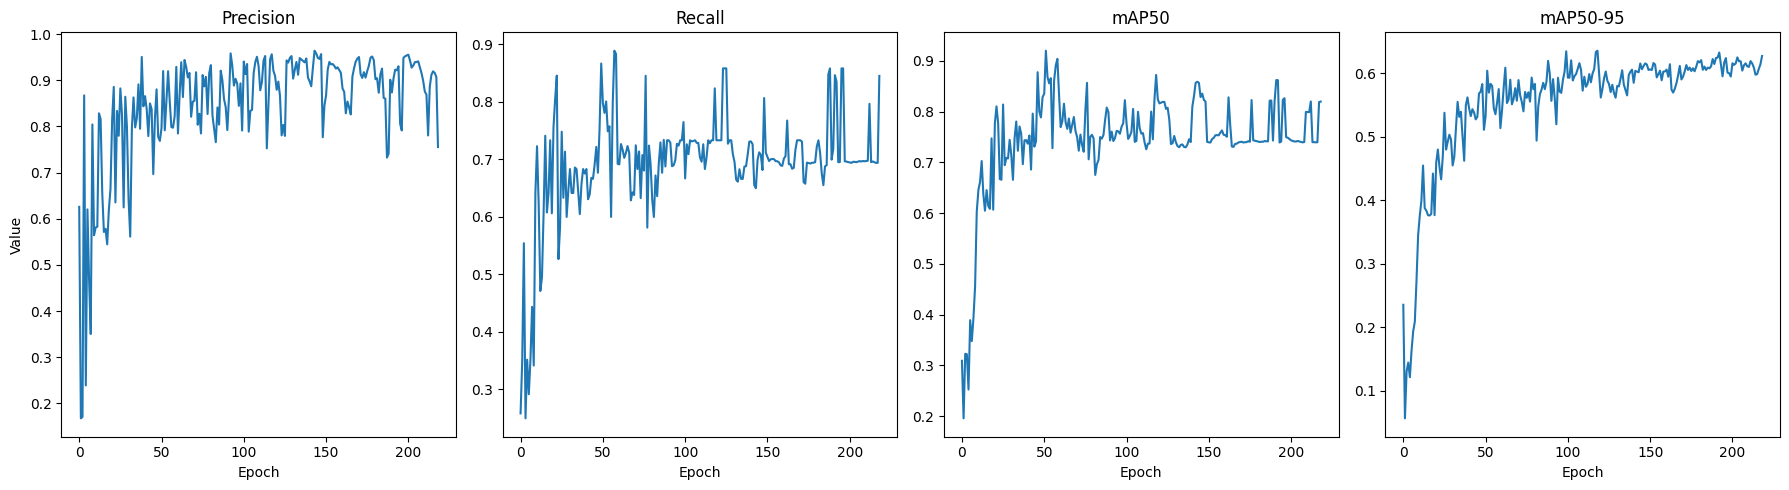

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Precision
axes[0].plot(smbt_detection_9.index, smbt_detection_9['metrics/precision(B)'])
axes[0].set_title('Precision')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Value')

# Recall
axes[1].plot(smbt_detection_9.index, smbt_detection_9['metrics/recall(B)'])
axes[1].set_title('Recall')
axes[1].set_xlabel('Epoch')

# mAP50
axes[2].plot(smbt_detection_9.index, smbt_detection_9['metrics/mAP50(B)'])
axes[2].set_title('mAP50')
axes[2].set_xlabel('Epoch')

# mAP50-95
axes[3].plot(smbt_detection_9.index, smbt_detection_9['metrics/mAP50-95(B)'])
axes[3].set_title('mAP50-95')
axes[3].set_xlabel('Epoch')

plt.tight_layout()
plt.show()

## <span style="color:#1f77b4;">IV. Detection Metrics Explanation</span>

### Precision
**Question it answers:**
*Of all detected objects, how many are correct?*

**Meaning:**
Precision measures how reliable the model’s detections are. High precision means few false positives (the model rarely detects objects that do not exist).

---

### Recall
**Question it answers:**
*Of all real objects in the image, how many did the model detect?*

**Meaning:**
Recall measures how complete the detections are. High recall means the model misses very few real objects.

---

### mAP50
**Question it answers:**
*How good is the model at detecting and roughly localizing objects when a moderate overlap is acceptable?*

**Meaning:**
mAP50 evaluates detection quality using an IoU threshold of 0.5. It is a more tolerant metric that reflects general detection performance.

---

### mAP50-95
**Question it answers:**
*How accurate is the model across different localization strictness levels?*

**Meaning:**
mAP50–95 averages performance over multiple IoU thresholds (0.5 to 0.95). It is a stricter and more realistic metric that strongly penalizes poor bounding box localization.
